---
title: Multi-parameter inference
---

Lets try to estimate both coalescent and migration rate in a two population model.

In [1]:
from phasic import (
    Graph, with_ipv, set_log_level,
    StateIndexer, Property,
    GaussPrior, HalfCauchyPrior, ExpStepSize, ExpRegularization, 
    clear_caches, clear_jax_cache, clear_model_cache,
)
import sys
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme

sns.set_palette('tab10')
set_vscode_theme()
np.random.seed(42)
_pytest = "pytest" in sys.modules

set_log_level('WARNING')

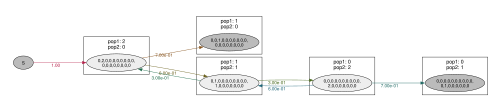

In [ ]:
nr_samples = 2

indexer = StateIndexer(
    descendants=[
    Property('pop1', min_value=0, max_value=nr_samples),
    Property('pop2', min_value=0, max_value=nr_samples),
    Property('in_pop', min_value=1, max_value=2),
])

initial = [0] * indexer.state_length

# set initial state with all lineages having one descendant at both loci
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []

    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)

        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, 
                    pop2=des_pop2, 
                    in_pop=props_i.in_pop
                    )
                child[k] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        if state[i] > 0:
            child = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child = state.copy()
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, 
                pop2=props_i.pop2, 
                in_pop=other_pop
                )
            child[k] += 1

            transitions.append([child, [0, state[i]]])

    return transitions

graph = Graph(two_island)   

true_theta = [0.7, 0.3]
graph.update_weights(true_theta)

def label(state):
    nr_pop1 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 1) for i in indexer])
    nr_pop2 = sum([state[i] * bool(indexer.index_to_props(i).descendants.in_pop == 2) for i in indexer])
    return f"pop1: {nr_pop1}\npop2: {nr_pop2}"

graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, 
                      by_state=label)

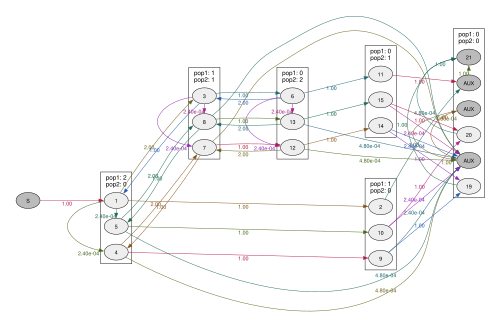

In [ ]:
mutation_rate = 1.2e-4
joint_prob_graph = graph.joint_prob_graph(indexer, 
                                          reward_only=['pop1', 'pop2'],
                                          reward_limit=1,
                                          tot_reward_limit=1, 
                                          mutation_rate=mutation_rate)

joint_prob_graph.plot(rankdir='LR', nodesep=0.3, ranksep=2,
                      wrap=10, label_fmt=lambda vertex: str(vertex.index()), by_state=label)

In [4]:
joint_prob_table = joint_prob_graph.joint_prob_table()
joint_prob_table

,pop1_0,pop1_1,pop1_2,pop2_0,pop2_1,pop2_2,prob
t_vertex_index,,,,,,,
18,0,0,0,0,0,0,0.999041
19,0,1,0,0,0,0,0.000479
20,0,0,0,1,0,0,0.000479


In [5]:
# nr_samples = 2

# indexer = StateIndexer(
#     descendants=[
#     Property('pop1', min_value=0, max_value=nr_samples),
#     Property('pop2', min_value=0, max_value=nr_samples),
#     Property('in_pop', min_value=1, max_value=2),
# ])

# initial = [0] * indexer.state_length

# # set initial state with all lineages having one descendant at both loci
# initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

# @with_ipv(initial)
# def two_island(state):
#     transitions = []

#     if state[indexer.descendants.indices()].sum() <= 1:
#         return transitions
    
#     for i in range(indexer.descendants.state_length):
#         if state[i] == 0: continue
#         props_i = indexer.descendants.index_to_props(i)

#         for j in range(i, indexer.descendants.state_length):
#             if state[j] == 0: continue
#             props_j = indexer.descendants.index_to_props(j)
            
#             if props_j.in_pop != props_i.in_pop:
#                 continue

#             same = int(i == j)
#             if same and state[i] < 2:
#                 continue
#             if not same and (state[i] < 1 or state[j] < 1):
#                 continue 

#             child = state.copy()
#             child[i] -= 1
#             child[j] -= 1
#             des_pop1 = props_i.pop1 + props_j.pop1
#             des_pop2 = props_i.pop2 + props_j.pop2
#             if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
#                 k = indexer.descendants.props_to_index(
#                     pop1=des_pop1, 
#                     pop2=des_pop2, 
#                     in_pop=props_i.in_pop
#                     )
#                 child[k] += 1
#                 transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

#         if state[i] > 0:
#             child = state.copy()
#             other_pop = 2 if props_i.in_pop == 1 else 1
#             child = state.copy()
#             child[i] -= 1
#             k = indexer.descendants.props_to_index(
#                 pop1=props_i.pop1, 
#                 pop2=props_i.pop2, 
#                 in_pop=other_pop
#                 )
#             child[k] += 1

#             transitions.append([child, [0, state[i]]])

#     return transitions

# graph = Graph(two_island)   

# true_theta = [0.7, 0.3]
# graph.update_weights(true_theta)
# graph.plot(rankdir='LR', by_index=lambda i: f"Desc in pop1: {indexer.index_to_props(i).descendants.pop1}")

In [6]:
# graph.plot(rankdir='LR', by_state=lambda s: f"In pop1: {s[indexer.descendants.props_to_index(pop1=1)].sum()}")

In [7]:
observations = graph.sample(1000)

In [8]:
svgd = graph.svgd(observations, 
                #   n_particles=40, n_iterations=100
                  )
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         0.7454     0.6800     0.1281     0.3752       0.7505      
1          No         0.3393     0.3488     0.2223     0.0000       0.6962      

Particles: 40, Iterations: 100


<Figure size 640x480 with 0 Axes>

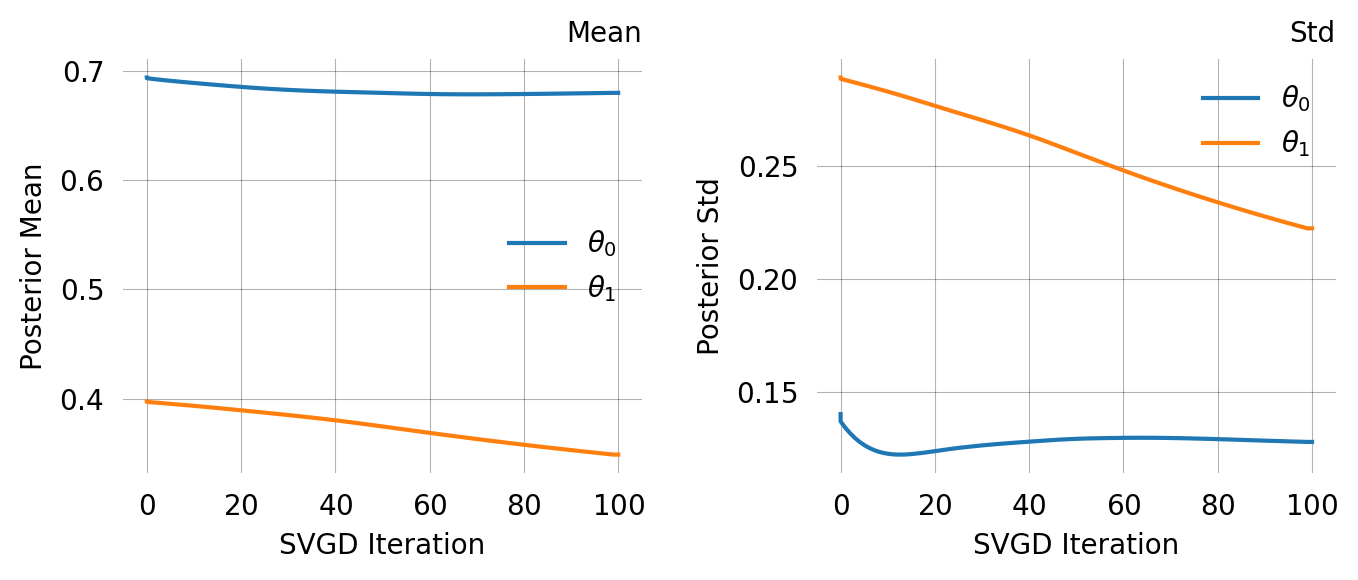

In [9]:
svgd.plot_convergence()

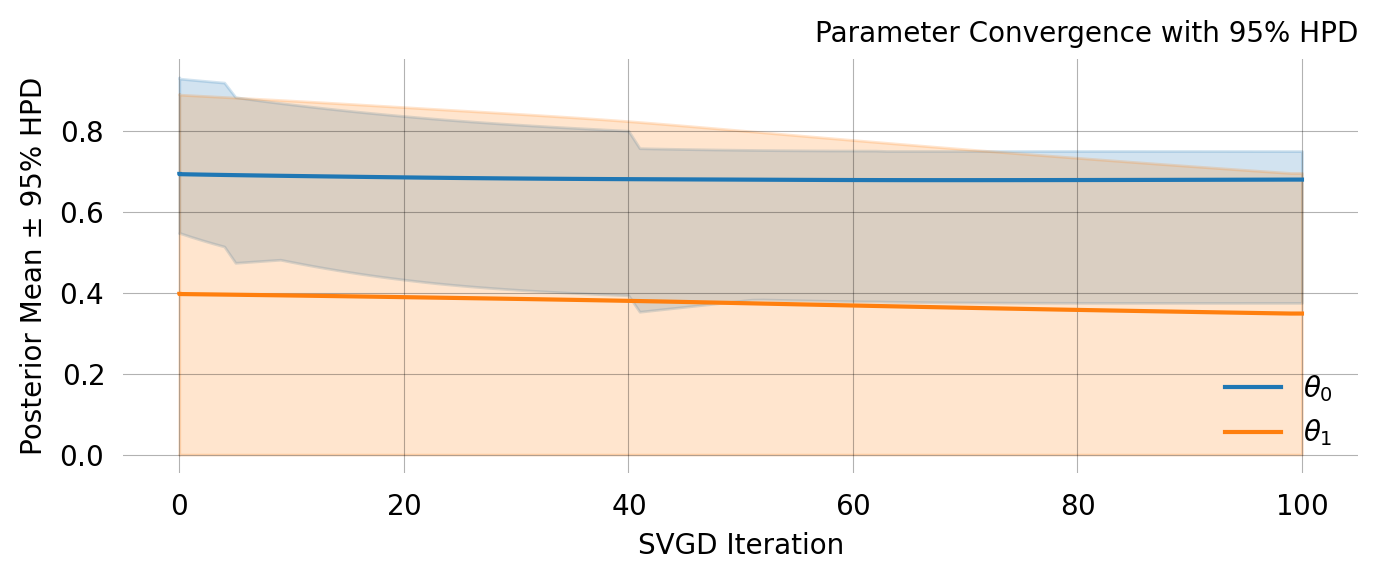

In [10]:
svgd.plot_ci()

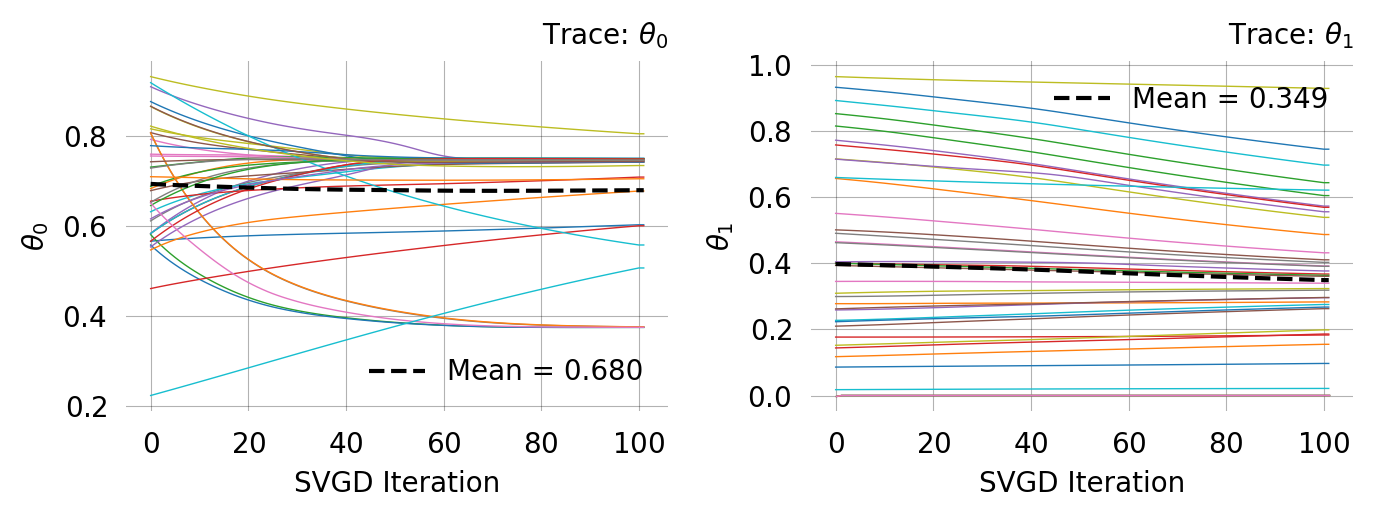

In [11]:
svgd.plot_trace()

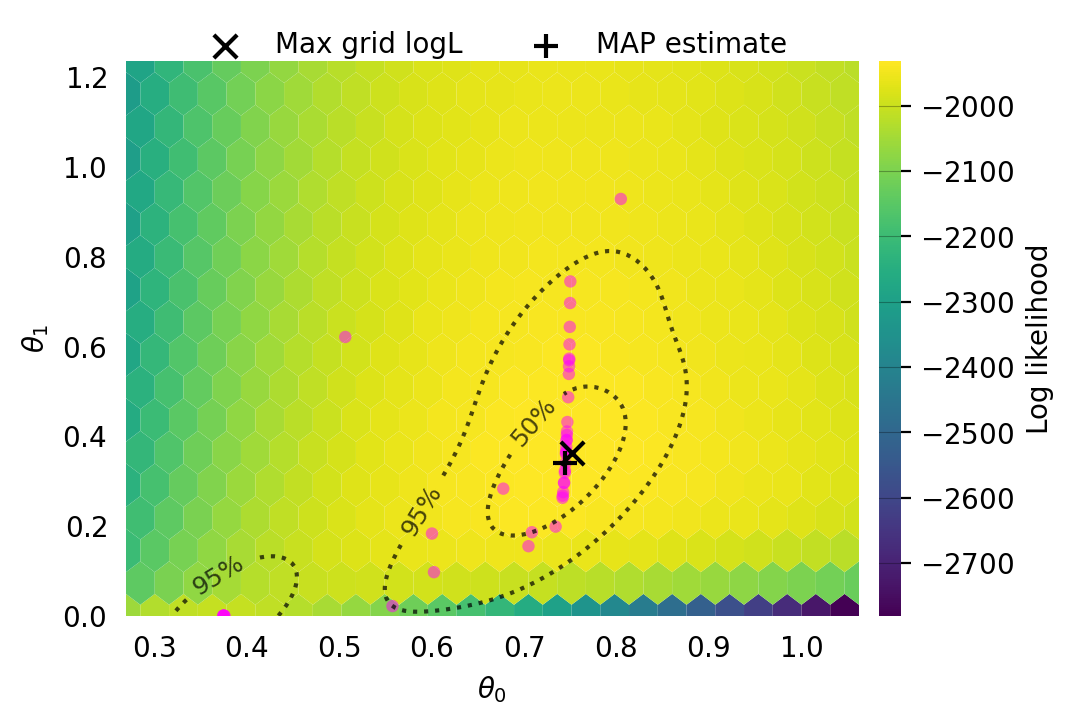

In [12]:
svgd.plot_hdr()

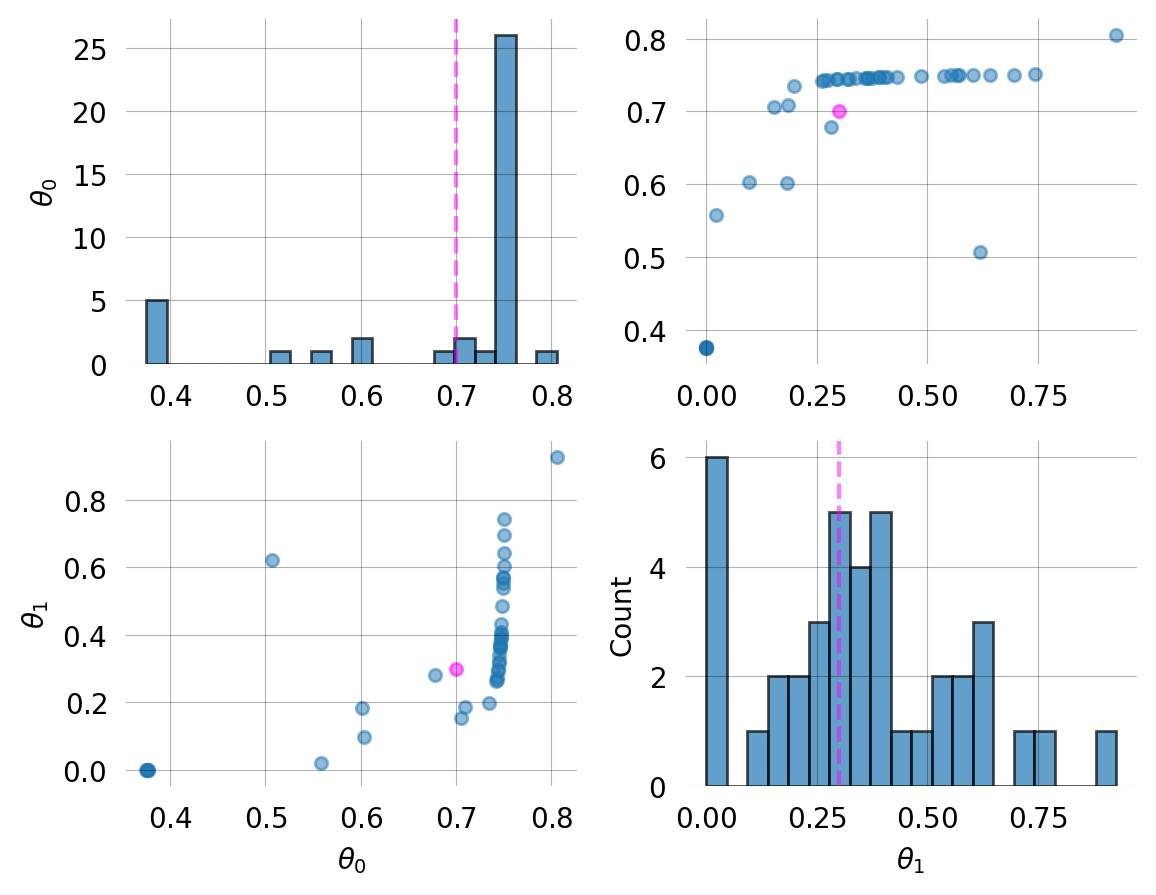

In [13]:
svgd.plot_pairwise(true_theta=true_theta)

In [14]:
#svgd.animate_pairwise(true_theta=true_theta)